The PPMI repository contains the full set of clinical, imaging and biological data collected as part of this ongoing study along with processed images and biospecimen analysis results. The repository is updated regularly as longitudinal follow-up of study subjects continues and data generated from a variety of CSF, DNA, serum, plasma and RNA analysis techniques are completed.

# Setup and Libraries

In [393]:
# Cell 0: get current notebook path, its parent, and project root (parent of parent)
import os
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: improve plots appearance
sns.set(style="whitegrid")

ROOT_DIR = Path(os.getcwd()).resolve().parents[1]

# Load the CSV and parse Imaging Protocol

In [394]:
CSV_DIR = ROOT_DIR / "csv_dir"
# original_df = pd.read_csv(CSV_DIR / "PPMI_all.csv")
# original_df = pd.read_csv(CSV_DIR / "PPMI_idaSearch_MRI_PET_SPECT.csv")
original_df = pd.read_csv(CSV_DIR / "PPMI_all.csv")
# original_df = pd.read_csv(CSV_DIR / "PPMI_idaSearch_MRI.csv")

ppmi_imaging_descriptions_path = "/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_imaging_descriptions.json"
ppmi_imaging_ignored_path = "/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_imaging_ignored.csv"


# little adjustments
original_df["Subject ID"] = original_df["Subject ID"].astype("category")
original_df["Image ID"] = original_df["Image ID"].astype("category")
original_df["Weight"] = original_df["Weight"].replace(0, np.nan)
original_df["Age"] = original_df["Age"].replace(0, np.nan)
original_df["Study Date"] = pd.to_datetime(original_df["Study Date"], errors="coerce")


fields = [
    "Acquisition Plane",
    "Slice Thickness",
    "Matrix Z",
    "Acquisition Type",
    "Manufacturer",
    "Mfg Model",
    "Field Strength",
    "Weighting",
]

numeric_fields = ["Slice Thickness", "Matrix Z", "Field Strength"]


def parse_imaging_protocol(text):
    if pd.isna(text):
        return {}

    items = text.split(";")
    parsed = {}

    for item in items:
        if "=" in item:
            key, value = item.split("=", 1)
            parsed[key.strip()] = value.strip()

    return parsed


# Parse the column into dictionaries
protocol_parsed = original_df["Imaging Protocol"].apply(parse_imaging_protocol)

# Create new columns
for field in fields:
    original_df[field] = protocol_parsed.apply(lambda x: x.get(field, np.nan))


for field in numeric_fields:
    original_df[field] = pd.to_numeric(original_df[field], errors="coerce")

print(original_df.columns)
print(original_df.head(1))
print(len(original_df))
print(original_df["Modality"].unique())


Index(['Subject ID', 'Project', 'Sex', 'Weight', 'Research Group', 'Visit',
       'Study Date', 'Archive Date', 'Age', 'GDSCALE Total Score', 'Modality',
       'Description', 'Type', 'Imaging Protocol', 'Image ID', 'Structure',
       'Laterality', 'Image Type', 'Registration', 'Tissue',
       'Acquisition Plane', 'Slice Thickness', 'Matrix Z', 'Acquisition Type',
       'Manufacturer', 'Mfg Model', 'Field Strength', 'Weighting'],
      dtype='str')
  Subject ID Project Sex  Weight Research Group      Visit Study Date  \
0     100001    PPMI   M     NaN             PD  Screening 2020-09-09   

  Archive Date   Age  GDSCALE Total Score  ... Registration Tissue  \
0    6/01/2021  67.3                  NaN  ...       native    All   

  Acquisition Plane Slice Thickness Matrix Z Acquisition Type Manufacturer  \
0               NaN             NaN      NaN              NaN   SIEMENS NM   

  Mfg Model Field Strength Weighting  
0       NaN            NaN       NaN  

[1 rows x 28 column

# Filtered dataframe - advanced modality

In [395]:
df = original_df[~original_df["Modality"].isin(["Path", "CT"])].copy()


with open(ppmi_imaging_descriptions_path, "r") as f:
    modality_dict = json.load(f)


def normalize_list(lst):
    return [s.strip().upper() for s in lst]


dwi_set = set(normalize_list(modality_dict["dwi"]))
func_set = set(normalize_list(modality_dict["func"]))

anat_sets = {k: set(normalize_list(v)) for k, v in modality_dict["anat"].items()}


ignore_df = pd.read_csv(ppmi_imaging_ignored_path)
ignore_set = set(ignore_df["Description"].str.strip().str.upper())


df["Description_clean"] = df["Description"].astype(str).str.strip().str.upper()


df = df[~df["Description_clean"].isin(ignore_set)].copy()


def classify_advanced(row):
    desc = row["Description_clean"]
    modality = row["Modality"]

    # --- DWI ---
    if desc in dwi_set:
        return "DWI"

    # --- Functional ---
    if desc in func_set:
        return "rsfMRI"

    # --- Anatomical ---
    for anat_type, anat_set in anat_sets.items():
        if desc in anat_set:
            return anat_type  # T1w, T2w, T2starw, FLAIR

    # --- Nuclear imaging ---
    if modality == "PET":
        return "PET"

    if modality == "SPECT":
        return "SPECT"

    # --- fallback ---
    if modality == "MRI":
        return "MRI_other"

    if modality == "fMRI":
        return "fMRI_other"

    return "Unknown"


df["Advanced_Modality"] = df.apply(classify_advanced, axis=1)

print(df["Advanced_Modality"].value_counts())
pd.crosstab(df["Modality"], df["Advanced_Modality"])


Advanced_Modality
T1w          17590
Unknown      17148
DWI          14968
SPECT         8532
rsfMRI        7254
T2w           6114
FLAIR         4293
MRI_other     2660
PET            762
T2starw          5
Name: count, dtype: int64


Advanced_Modality,DWI,FLAIR,MRI_other,PET,SPECT,T1w,T2starw,T2w,Unknown,rsfMRI
Modality,,,,,,,,,,
DTI,12169,0,0,0,0,19,0,36,17148,0
MRI,2711,4293,2660,0,0,17280,5,6078,0,3637
PET,0,0,0,762,0,0,0,0,0,0
SPECT,20,0,0,0,8532,0,0,0,0,0
fMRI,68,0,0,0,0,291,0,0,0,3617


In [396]:
# Apply filters


df = df[
    # (df["Advanced_Modality"].isin(["DWI"]))
    # (df["Advanced_Modality"].isin(["T2w"]))
    (df["Advanced_Modality"].isin(["T1w", "FLAIR"]))
    # (df["Modality"] == "MRI")
    # ((df["Modality"] == "SPECT") | (df["Modality"] == "MRI"))
    # & (df["Weighting"] == "T1")
    # & (df["Field Strength"] > 1.4)
    # & (df["Matrix Z"] > 100)
    # & (df["Slice Thickness"] < 1.4)
    & (df["Acquisition Type"] == "3D")
    # & ~df["Description"].str.contains("flair", case=False, na=False)
    # & ~df["Description"].str.contains("fmri", case=False, na=False)
    # & ~df["Description"].str.contains("t2", case=False, na=False)
    # & df["Description"].str.lower().str.startswith("t1")
    # & (df["Type"] == "Pre-processed")
    # & df["Description"].str.contains(r"t1|mprage", case=False, na=False)
    # & df["Description"].str.contains(r"mprage", case=False, na=False)
    # & df["Description"].str.contains(r"t2", case=False, na=False)
    # & df["Description"].str.contains(r"Ax T1 FLAIR", case=False, na=False)
    # & (df["Type"] == "Original")
].copy()

print(
    f"Filtered dataset size: {df.shape[0]} images from {df['Subject ID'].nunique()} subjects."
)

# print(df["Description"].unique())
print("Number of unique descriptions:", len(df["Description"].unique()))

Filtered dataset size: 9416 images from 3168 subjects.
Number of unique descriptions: 159


### No filter

In [ ]:
# df = original_df
# print(df["Modality"].unique())
# df.head(2)

# Basic descriptions

In [399]:
# # print("=== Columns in the Dataset ===")
# # display(pd.DataFrame(df.columns, columns=["Column Names"]))

# print("\n=== Numeric Features Summary ===")
# display(df.describe().round(2))  # round to 2 decimals

# print("\n=== Categorical Features Summary ===")
# display(df.describe(include=["object", "category"]))

# missing_count = df.isnull().sum()
# missing_percent = (missing_count / len(df) * 100).round(2)
# missing_df = pd.DataFrame(
#     {"Missing Count": missing_count, "Missing %": missing_percent}
# ).sort_values(by="Missing Count", ascending=False)

# print("\n=== Missing Values by Column ===")
# display(missing_df)

# cols_with_missing = df.columns[df.isnull().any()]
# print(f"Columns with missing values ({len(cols_with_missing)}):\n")


# Histograms

/tmp/ipykernel_53803/2137638403.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


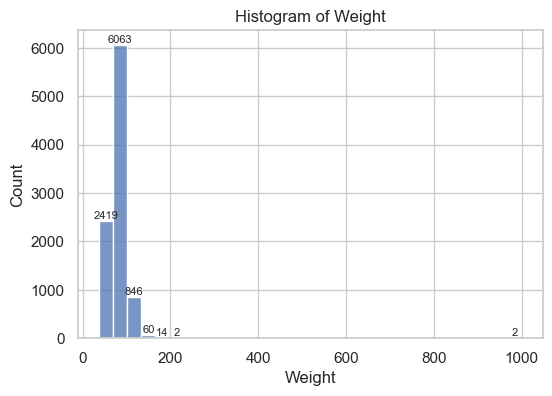

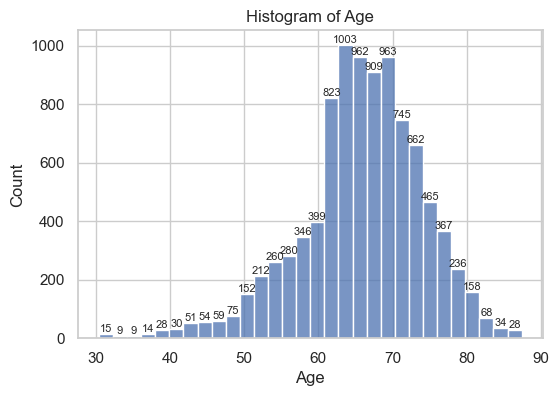

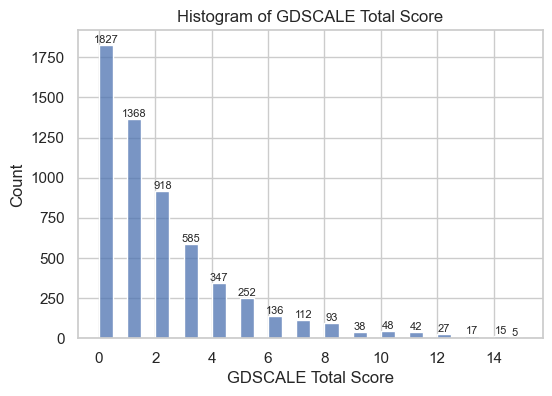

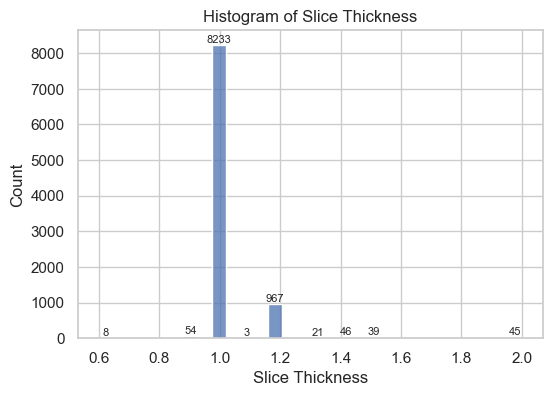

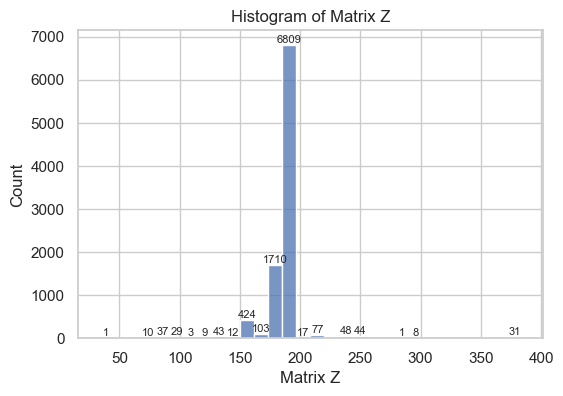

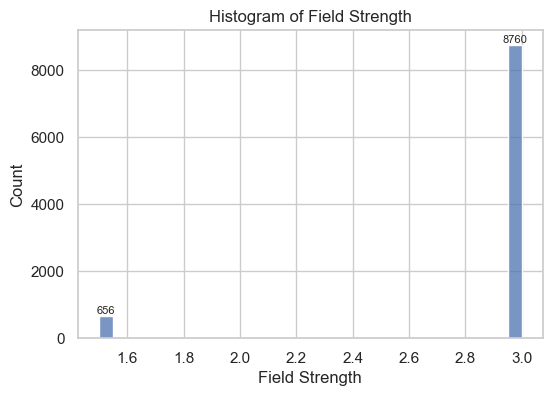

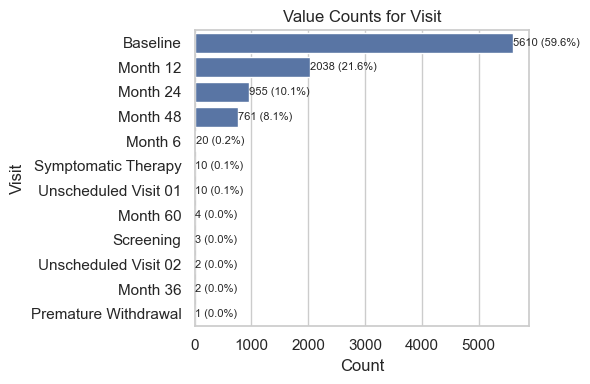

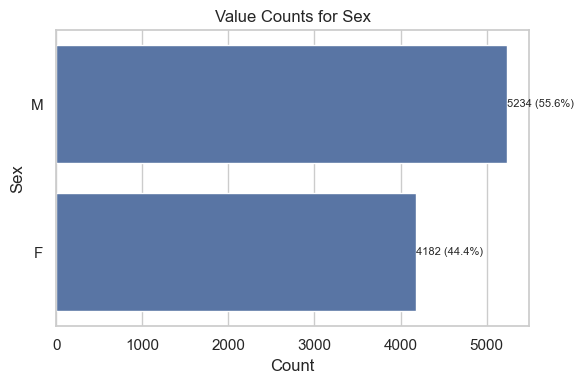

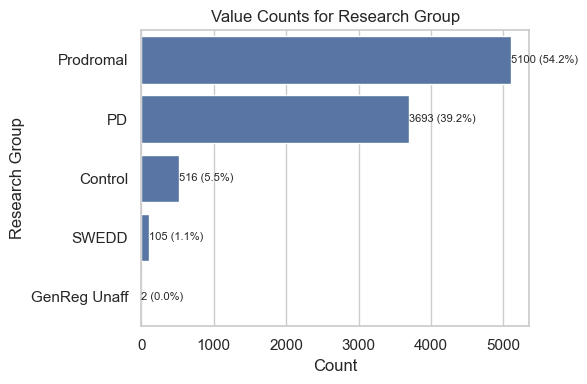

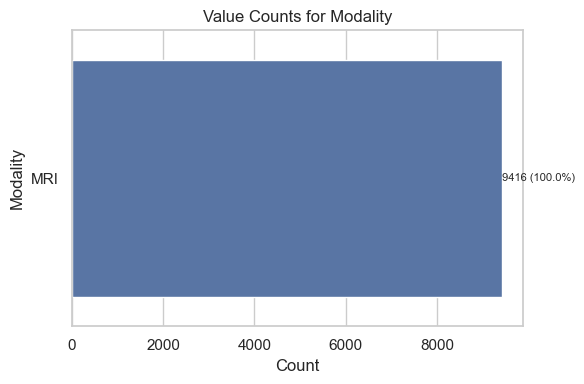

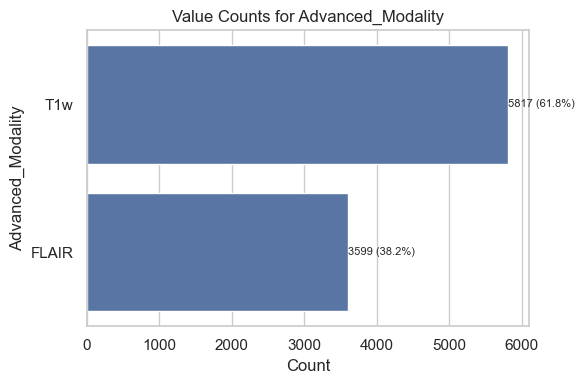

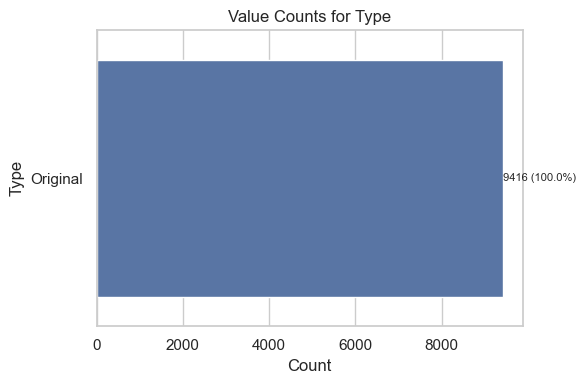

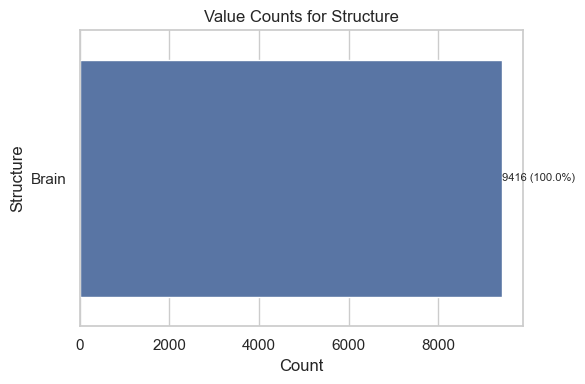

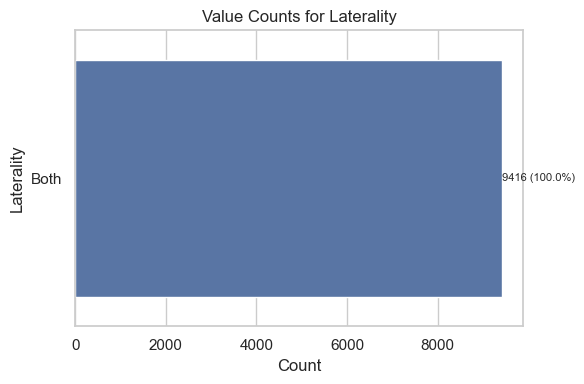

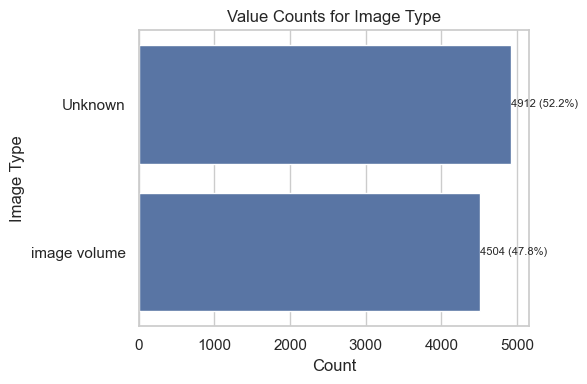

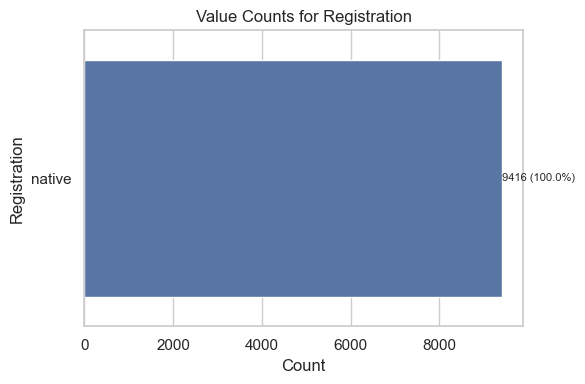

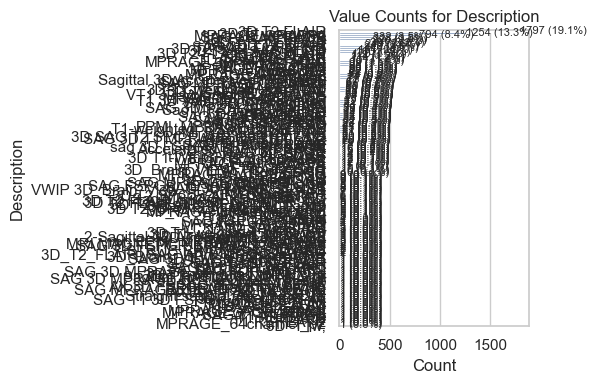

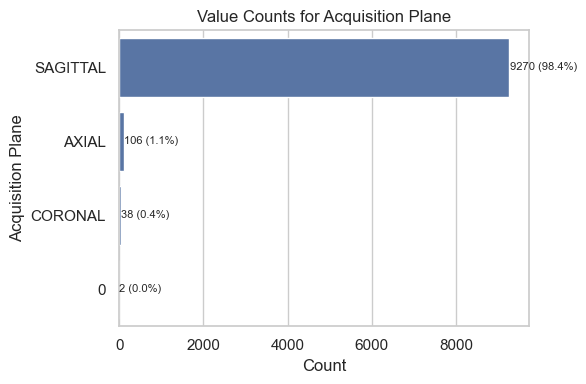

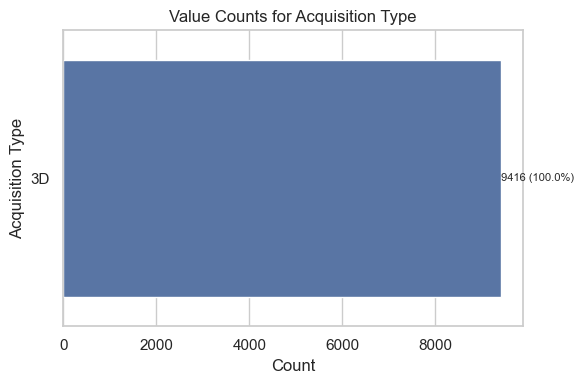

In [400]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

# -------------------------------
# Numeric Columns Histograms
# -------------------------------
for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    # Plot histogram
    ax = sns.histplot(
        df[col].dropna(), bins=30, kde=False
    )  # disable KDE for counts clarity

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    # Annotate counts on top of each bin
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:  # only annotate non-empty bins
            ax.text(
                patch.get_x() + patch.get_width() / 2,  # center of bin
                height + 0.5,  # slightly above the bar
                int(height),  # show integer count
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.show()

# -------------------------------
# Categorical Columns Bar Plots
# -------------------------------
categorical_cols = [
    "Visit",
    "Sex",
    "Research Group",
    "Modality",
    "Advanced_Modality",
    "Type",
    "Structure",
    "Laterality",
    "Image Type",
    "Registration",
    "Description",
    # "Tissue",
    "Acquisition Plane",
    "Acquisition Type",
    # "Manufacturer",
    # "Mfg Model",
    # "Weighting",
]

categorical_cols = [col for col in categorical_cols if col in df.columns]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))

    df[col] = df[col].fillna("Unknown").astype(str)

    # Compute counts after cleaning
    counts = df[col].value_counts()
    total = counts.sum()
    order = counts.index.tolist()  # already strings

    ax = sns.countplot(y=col, data=df, order=order)

    for p, category in zip(ax.patches, order):
        count = counts.get(category, 0)
        percent = 100 * count / total

        ax.text(
            p.get_width() + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{count} ({percent:.1f}%)",
            va="center",
            fontsize=8,
        )

    plt.title(f"Value Counts for {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# Multimodal inspection

### Simultaneous Multimodal Availability (Per Visit)

In [401]:
# Unique subject-visit-modality combinations
visit_modalities = (
    df.groupby(["Subject ID", "Visit"])["Advanced_Modality"].unique().reset_index()
)

visit_modalities["n_modalities"] = visit_modalities["Advanced_Modality"].apply(len)
print(visit_modalities["n_modalities"].value_counts())
print(visit_modalities["n_modalities"].describe())


n_modalities
2    3163
1    1894
Name: count, dtype: int64
count    5057.000000
mean        1.625470
std         0.484049
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: n_modalities, dtype: float64


In [ ]:
# Pivot to binary presence matrix
visit_modality_matrix = (
    df.assign(present=1)
    .drop_duplicates(["Subject ID", "Visit", "Advanced_Modality"])
    .pivot_table(
        index=["Subject ID", "Visit"],
        columns="Advanced_Modality",
        values="present",
        fill_value=0,
    )
)
co_occurrence = visit_modality_matrix.T @ visit_modality_matrix
print(co_occurrence)

Advanced_Modality   FLAIR     T1w
Advanced_Modality                
FLAIR              3167.0  3163.0
T1w                3163.0  5053.0


### multimodal through time

In [403]:
subject_time_modalities = (
    df.groupby(["Subject ID", "Visit"])["Advanced_Modality"]
    .nunique()
    .reset_index(name="n_modalities")
)
subject_time_modalities.groupby("Visit")["n_modalities"].mean()


Visit
Baseline                1.602932
Month 12                1.764004
Month 24                1.551020
Month 36                1.000000
Month 48                1.534954
Month 6                 2.000000
Month 60                2.000000
Premature Withdrawal    1.000000
Screening               1.000000
Symptomatic Therapy     1.000000
Unscheduled Visit 01    1.000000
Unscheduled Visit 02    1.000000
Name: n_modalities, dtype: float64

In [404]:
# Make sure Advanced_Modality is string and cleaned
df["Advanced_Modality"] = df["Advanced_Modality"].fillna("Unknown").astype(str)

# Generate presence/absence matrix
modality_matrix = pd.crosstab(
    index=[df["Subject ID"], df["Visit"]],  # rows
    columns=df["Advanced_Modality"],  # columns
)

# Convert counts >0 to 1 (presence)
modality_matrix = (modality_matrix > 0).astype(int)

modality_matrix.reset_index(inplace=True)
modality_matrix.head()


Advanced_Modality,Subject ID,Visit,FLAIR,T1w
0,3000,Baseline,0,1
1,3001,Baseline,0,1
2,3002,Baseline,0,1
3,3003,Baseline,0,1
4,3004,Baseline,0,1


In [405]:
# Filter rows with at least 2 modalities
modality_matrix["n_modalities"] = modality_matrix.sum(axis=1)
modality_matrix_filtered = modality_matrix[modality_matrix["n_modalities"] >= 2]
# Drop the helper column
# Reset index to get Subject ID and Visit as columns
modality_matrix_filtered = modality_matrix_filtered.drop(columns=["n_modalities"])
modality_matrix_filtered = modality_matrix_filtered.reset_index()

Advanced_Modality,Subject ID,Visit,FLAIR,T1w
0,40067,Month 48,1,1
1,40533,Month 48,1,1
2,40542,Month 48,1,1
3,40543,Month 48,1,1
4,40735,Month 48,1,1


# longitudinal analysis

In [406]:
# keep only Subject ID and Visit
# Merge with original df to keep only rows matching valid visits
valid_visits = modality_matrix_filtered[["Subject ID", "Visit"]]
df_filtered = df.merge(valid_visits, on=["Subject ID", "Visit"], how="inner")

print(f"Original df: {df.shape[0]} rows")
print(f"Filtered df (≥2 modalities per visit): {df_filtered.shape[0]} rows")

Original df: 9416 rows
Filtered df (≥2 modalities per visit): 6972 rows


Longitudinal Coverage per Subject (Scheduled Visits, ≥2 modalities):


count    2097.000000
mean        1.508345
std         0.696948
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: Visit_Months, dtype: float64

/tmp/ipykernel_53803/2840689086.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=visit_counts.index, y=visit_counts.values, palette="Blues_d")


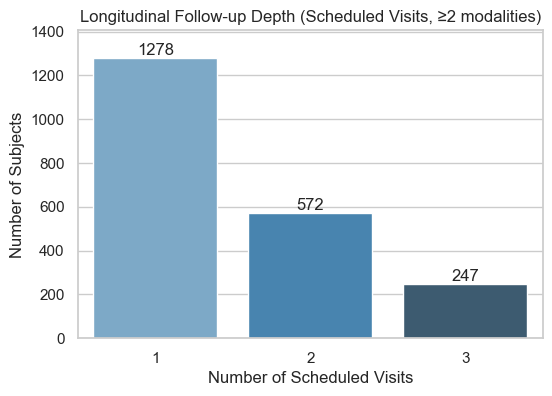

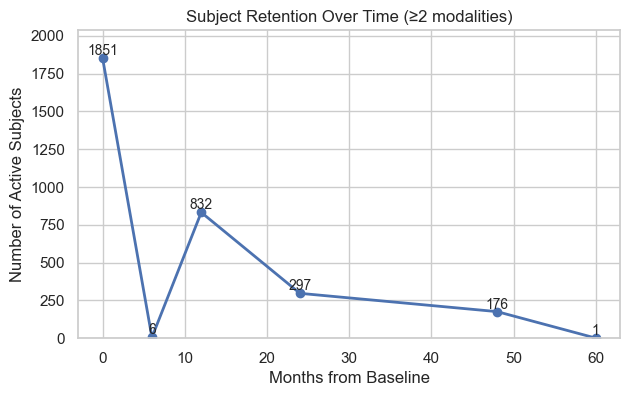

/tmp/ipykernel_53803/2840689086.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=retention.index, y=retention.values, palette="Blues_d")


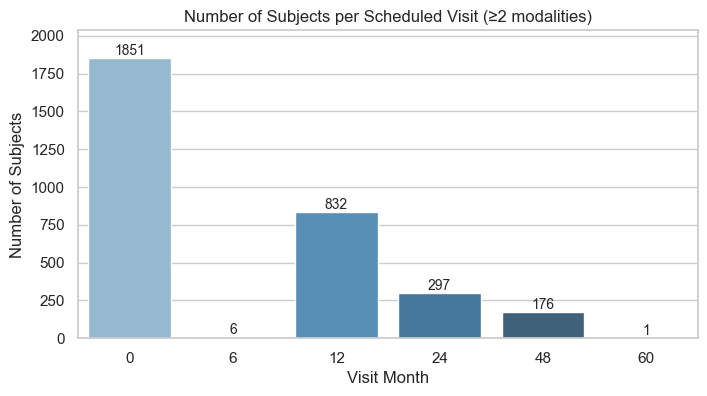

In [407]:
import re
import numpy as np

# Get unique visit names
visit_values = df_filtered["Visit"].unique()

scheduled_visits = {}
event_visits = []

for v in visit_values:
    v_clean = str(v).strip()
    if v_clean.lower() in ["baseline", "screening", "other screening"]:
        scheduled_visits[v_clean] = 0
    elif re.match(r"Month\s*(\d+)", v_clean, re.IGNORECASE):
        month_num = int(re.match(r"Month\s*(\d+)", v_clean, re.IGNORECASE).group(1))
        scheduled_visits[v_clean] = month_num
    else:
        event_visits.append(v_clean)

# Map scheduled visits to months
df_filtered["Visit_Months"] = df_filtered["Visit"].map(scheduled_visits)
df_filtered["Visit_Type"] = np.where(
    df_filtered["Visit"].isin(scheduled_visits.keys()), "Scheduled", "Event"
)

# Keep only scheduled visits
scheduled_df = df_filtered[df_filtered["Visit_Type"] == "Scheduled"].copy()

# Count unique scheduled visits per subject
visits_per_subject = (
    scheduled_df.groupby("Subject ID", observed=True)["Visit_Months"]
    .nunique()
    .sort_values(ascending=False)
)

# Summary statistics
summary_stats = visits_per_subject.describe()
print("Longitudinal Coverage per Subject (Scheduled Visits, ≥2 modalities):")
display(summary_stats)

# -------------------------------
# Barplot with counts on top
# -------------------------------
visit_counts = visits_per_subject.value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=visit_counts.index, y=visit_counts.values, palette="Blues_d")

for i, v in enumerate(visit_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", va="bottom")

plt.xlabel("Number of Scheduled Visits")
plt.ylabel("Number of Subjects")
plt.title("Longitudinal Follow-up Depth (Scheduled Visits, ≥2 modalities)")
plt.xticks(range(len(visit_counts.index)), visit_counts.index)
plt.ylim(0, visit_counts.values.max() * 1.1)
plt.show()

# -----------------------------
# Retention over time
# -----------------------------
retention = (
    scheduled_df.groupby("Visit_Months", observed=True)["Subject ID"]
    .nunique()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.plot(retention.index, retention.values, marker="o", linewidth=2)
for x, y in zip(retention.index, retention.values):
    plt.text(x, y + 0.5, str(y), ha="center", va="bottom", fontsize=10)
plt.xlabel("Months from Baseline")
plt.ylabel("Number of Active Subjects")
plt.title("Subject Retention Over Time (≥2 modalities)")
plt.grid(True)
plt.ylim(0, retention.values.max() * 1.1)
plt.show()

# -----------------------------
# Bar plot for retention
# -----------------------------
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=retention.index, y=retention.values, palette="Blues_d")
for i, v in enumerate(retention.values):
    ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=10)
plt.xlabel("Visit Month")
plt.ylabel("Number of Subjects")
plt.title("Number of Subjects per Scheduled Visit (≥2 modalities)")
plt.ylim(0, retention.values.max() * 1.1)
plt.show()
